# PXP ScarFinder From $Z_2$

This notebook uses the mixed ScarFinder interface
$\mathrm{scarfinder\_step!}(\psi, G, h, \chi; \ldots)$, where:

- $G$ is the local gate actually applied on the manifold,
- $h$ is the local Hamiltonian used for energy fixing.

Here we use a projected PXP gate of the form $G = \Pi U$, where $\Pi$ enforces the local no-double-excitation constraint. This projector is important because ScarFinder truncation can introduce small unphysical components, and the projection step pushes the state back toward the constrained PXP manifold.

We start from the $Z_2$ product state, search on the $\chi = 2$ manifold for 200 steps, then evolve for 50 additional ScarFinder steps and select the state with maximal overlap with $Z_2$.

## Parameters

We follow the requested setup:

- $\chi = 2$
- initialization from $Z_2$
- search step size $dt = 0.01$
- dynamics sampling interval $\Delta t = 0.1$
- $\mathrm{maxdim} = 32$
- 200 ScarFinder search steps
- 50 extra steps for overlap-based selection

In [1]:
import Pkg
Pkg.activate("..")

using iTEBD, LinearAlgebra, Plots

default(linewidth=2, framestyle=:box, legend=:topright, size=(950, 320))

  Activating project at `~/Library/CloudStorage/OneDrive-UniversityofLeeds/GitHub/iTEBD.jl`


## Local PXP Data

We use the standard three-site PXP Hamiltonian density

$$h = P \otimes X \otimes P,$$

and build a projected gate

$$G = \Pi \exp(-i \, dt \, h),$$

with a local constraint projector $\Pi$ that removes configurations with adjacent excitations inside the three-site support.

Equivalently, $\Pi$ is the three-site projector onto the subspace with no nearest-neighbour pair $11$.

In [2]:
# Local two-level operators.
# P0 is the projector entering the PXP Hamiltonian.
# N1 is the excitation projector used in the blockade constraint.
P0 = [0 0; 0 1]
N1 = [1 0; 0 0]
X = [0 1; 1 0]
Z = [1 0; 0 -1]

# Three-site PXP Hamiltonian density and local projector.
h_pxp = kron(P0, X, P0)

# Two-site projector onto the allowed subspace with no adjacent excitations.
no_double_2 = Matrix{Float64}(I, 4, 4) - kron(N1, N1)

# Three-site constraint projector. Since the two pair projectors commute,
# their product is again a projector onto the locally physical subspace.
proj_pxp = kron(no_double_2, I(2)) * kron(I(2), no_double_2)

# Search and dynamics parameters.
chi = 2
dt = 0.01
Delta_t = 0.1
maxdim = 32
search_steps = 200
selection_steps = 50
span = 3

# Gate used on the ScarFinder manifold.
U_search = exp(-1im * dt * h_pxp)
G_search = proj_pxp * U_search

# Unitary gate used later for real-time dynamics plots.
U_dynamics = exp(-1im * Delta_t * h_pxp)

function z2_state()
    product_iMPS(ComplexF64, [[0, 1], [1, 0], [0, 1], [1, 0]])
end

function z2_shifted_state()
    product_iMPS(ComplexF64, [[1, 0], [0, 1], [1, 0], [0, 1]])
end

fidelity_density(psi_ref::iMPS, psi::iMPS) = maximum(abs2.(eigvals(iTEBD.gtrm(psi_ref, psi))))

function z2_manifold_overlap(psi::iMPS, psi_z2::iMPS, psi_z2_shifted::iMPS)
    max(fidelity_density(psi_z2, psi), fidelity_density(psi_z2_shifted, psi))
end

zz_density(psi::iMPS) = 0.5 * (iTEBD.expect(psi, kron(Z, Z), 1, 2) + iTEBD.expect(psi, kron(Z, Z), 2, 3))

zz_density (generic function with 1 method)

## Initial State And Target Energy

We use the `Z_2` product state both as the initial state and as the reference for the overlap-based selection step. The target energy for energy fixing is chosen from the `Z_2` expectation value of the local Hamiltonian density `h_pxp`.

In [3]:
psi_z2 = z2_state()
psi_z2_shifted = z2_shifted_state()
target_energy = energy_density(psi_z2, h_pxp; span=span)

(;
    target_energy,
    initial_entropy=iTEBD.ent_S(psi_z2, psi_z2.n),
    initial_overlap=z2_manifold_overlap(psi_z2, psi_z2, psi_z2_shifted),
)

(target_energy = 0.0, initial_entropy = 0.0, initial_overlap = 1.0)

## 200-Step ScarFinder Search

At each step we apply the projected gate $G_{\mathrm{search}}$ ten times, so one ScarFinder step corresponds to the requested physical interval $\Delta t = 10 \, dt = 0.1$. We then truncate back to $\chi = 2$ and use $h_{\mathrm{pxp}}$ to perform the energy-fixing correction. The projection part is there specifically to clean up locally unphysical weight created by truncation.

In [4]:
psi_search = z2_state()

energy_hist = zeros(search_steps)
entropy_hist = zeros(search_steps)
overlap_hist = zeros(search_steps)
zz_hist = zeros(search_steps)

for step in 1:search_steps
    scarfinder_step!(psi_search, G_search, h_pxp, chi;
        span=span,
        hspan=span,
        nstep=10,
        target=target_energy,
        maxdim=maxdim,
    )

    energy_hist[step] = energy_density(psi_search, h_pxp; span=span)
    entropy_hist[step] = iTEBD.ent_S(psi_search, psi_search.n)
    overlap_hist[step] = z2_manifold_overlap(psi_search, psi_z2, psi_z2_shifted)
    zz_hist[step] = zz_density(psi_search)
end

(;
    final_energy=energy_hist[end],
    final_entropy=entropy_hist[end],
    final_overlap=overlap_hist[end],
    final_zz=zz_hist[end],
)

(final_energy = 1.3151783316280414e-14, final_entropy = 0.1666019215534055, final_overlap = 0.22895168370863, final_zz = 0.053537353060174854)

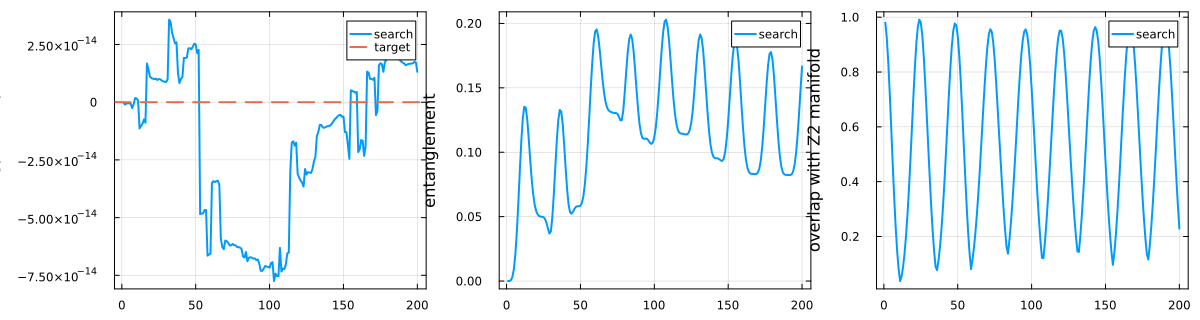

In [5]:
p1 = plot(1:search_steps, energy_hist, xlabel="search step", ylabel="energy density", label="search")
hline!(p1, [target_energy], linestyle=:dash, label="target")

p2 = plot(1:search_steps, entropy_hist, xlabel="search step", ylabel="entanglement", label="search")

p3 = plot(1:search_steps, overlap_hist, xlabel="search step", ylabel="overlap with Z2 manifold", label="search")

plot(p1, p2, p3; layout=(1, 3), size=(1200, 320))

## Additional 50 Steps: Select Maximal Overlap With $Z_2$

This selection stage is separate from the built-in entropy-based refinement. We explicitly evolve a trial copy for 50 additional ScarFinder steps, record the overlap with $Z_2$, and then move the working state to the best point on that trajectory.

In [6]:
function select_max_overlap!(psi::iMPS, psi_z2::iMPS, psi_z2_shifted::iMPS, G::AbstractMatrix, h::AbstractMatrix, chi::Integer;
    select_steps::Integer,
    span::Integer,
    hspan::Integer,
    target::Union{Real,Nothing}=nothing,
    maxdim::Integer=32,
)
    psi_trial = deepcopy(psi)
    overlaps = zeros(select_steps)
    entropies = zeros(select_steps)
    energies = zeros(select_steps)

    for step in 1:select_steps
        scarfinder_step!(psi_trial, G, h, chi;
            span=span,
            hspan=hspan,
            nstep=10,
            target=target,
            maxdim=maxdim,
        )
        overlaps[step] = z2_manifold_overlap(psi_trial, psi_z2, psi_z2_shifted)
        entropies[step] = iTEBD.ent_S(psi_trial, psi_trial.n)
        energies[step] = energy_density(psi_trial, h; span=hspan)
    end

    best_overlap, best_step = findmax(overlaps)

    for _ in 1:best_step
        scarfinder_step!(psi, G, h, chi;
            span=span,
            hspan=hspan,
            nstep=10,
            target=target,
            maxdim=maxdim,
        )
    end

    return (; best_step, best_overlap, overlaps, entropies, energies)
end

select_max_overlap! (generic function with 1 method)

In [7]:
psi_selected = deepcopy(psi_search)

selection = select_max_overlap!(psi_selected, psi_z2, psi_z2_shifted, G_search, h_pxp, chi;
    select_steps=selection_steps,
    span=span,
    hspan=span,
    target=target_energy,
    maxdim=maxdim,
)

(;
    best_selection_step=selection.best_step,
    best_selection_overlap=selection.best_overlap,
    selected_energy=energy_density(psi_selected, h_pxp; span=span),
    selected_entropy=iTEBD.ent_S(psi_selected, psi_selected.n),
    selected_overlap=z2_manifold_overlap(psi_selected, psi_z2, psi_z2_shifted),
)

(best_selection_step = 14, best_selection_overlap = 0.9621923256973949, selected_energy = 7.879628065804503e-15, selected_entropy = 0.0943933119160641, selected_overlap = 0.9621923256973949)

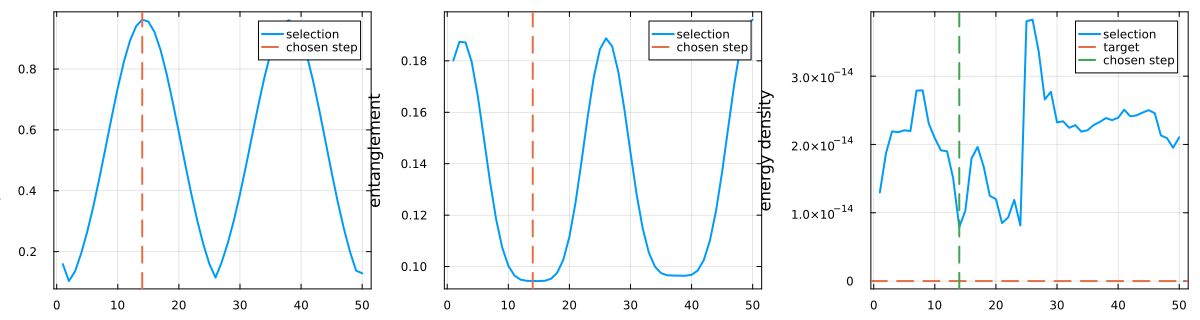

In [8]:
p1 = plot(1:selection_steps, selection.overlaps, xlabel="extra step", ylabel="overlap with Z2 manifold", label="selection")
vline!(p1, [selection.best_step], linestyle=:dash, label="chosen step")

p2 = plot(1:selection_steps, selection.entropies, xlabel="extra step", ylabel="entanglement", label="selection")
vline!(p2, [selection.best_step], linestyle=:dash, label="chosen step")

p3 = plot(1:selection_steps, selection.energies, xlabel="extra step", ylabel="energy density", label="selection")
hline!(p3, [target_energy], linestyle=:dash, label="target")
vline!(p3, [selection.best_step], linestyle=:dash, label="chosen step")

plot(p1, p2, p3; layout=(1, 3), size=(1200, 320))

## Scar Dynamics From The Selected State

Finally, we compare real-time PXP dynamics starting from:

- the original $Z_2$ state,
- the selected $\chi = 2$ ScarFinder state.

The dynamics are sampled with $\Delta t = 0.1$ as requested.

In [9]:
function evolve_unitary_pxp(psi0::iMPS, U::AbstractMatrix, h::AbstractMatrix;
    span::Integer,
    steps::Integer,
    maxdim::Integer=32,
    delta_t::Real=0.1,
)
    psi = deepcopy(psi0)
    times = collect(0:steps) .* delta_t
    entropy = zeros(steps + 1)
    overlap = zeros(steps + 1)
    energy = zeros(steps + 1)

    entropy[1] = iTEBD.ent_S(psi, psi.n)
    overlap[1] = fidelity_density(psi0, psi)
    energy[1] = energy_density(psi, h; span=span)

    for step in 1:steps
        for site in 1:psi.n
            applygate!(psi, U, site, mod(site + span - 1 - 1, psi.n) + 1; maxdim=maxdim)
        end
        entropy[step + 1] = iTEBD.ent_S(psi, psi.n)
        overlap[step + 1] = fidelity_density(psi0, psi)
        energy[step + 1] = energy_density(psi, h; span=span)
    end

    return (; times, entropy, overlap, energy)
end

evolve_unitary_pxp (generic function with 1 method)

In [10]:
dynamics_steps = 100

dyn_z2 = evolve_unitary_pxp(psi_z2, U_dynamics, h_pxp; span=span, steps=dynamics_steps, maxdim=maxdim, delta_t=Delta_t)
dyn_selected = evolve_unitary_pxp(psi_selected, U_dynamics, h_pxp; span=span, steps=dynamics_steps, maxdim=maxdim, delta_t=Delta_t)

(times = [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9  …  9.1, 9.200000000000001, 9.3, 9.4, 9.5, 9.600000000000001, 9.700000000000001, 9.8, 9.9, 10.0], entropy = [0.0943933119160641, 0.09445075460387153, 0.09474090724236248, 0.09589401665217058, 0.0989327301461608, 0.10502793836073601, 0.11507291160750374, 0.1291914827631144, 0.14642843418205242, 0.16480792651150322  …  0.23580103994908402, 0.2351169878393171, 0.2358245054845935, 0.23697455184991706, 0.23805979111822895, 0.23910208746174386, 0.24060514884317444, 0.2434118233177095, 0.24847442477832316, 0.25654653240936903], overlap = [1.0000000000000036, 0.9887036662543286, 0.9555204893521414, 0.9024995325813494, 0.8328365257087529, 0.7505737937597919, 0.660233661770735, 0.5664291572459967, 0.4734963598944161, 0.38518713586324077  …  0.8653173433235454, 0.9195362556713658, 0.958995242494947, 0.9808011694672446, 0.9827467629430905, 0.9635385204310495, 0.9229746389036915, 0.8620509164215

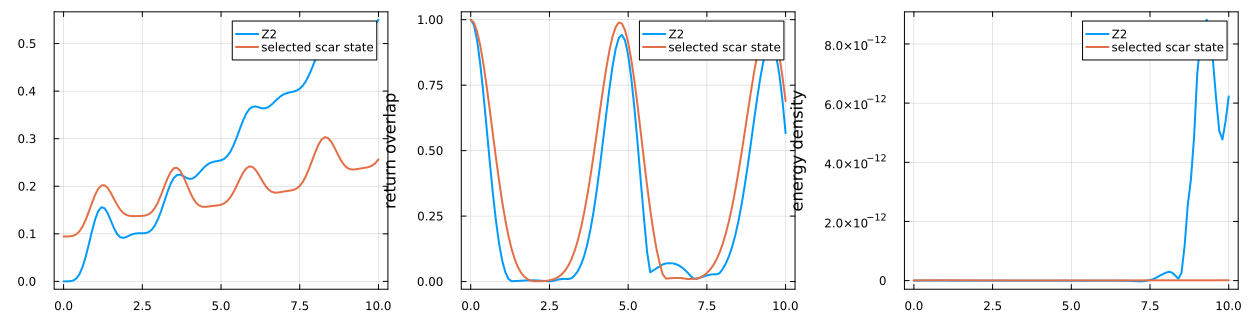

In [11]:
p1 = plot(dyn_z2.times, dyn_z2.entropy, xlabel="time", ylabel="entanglement", label="Z2")
plot!(p1, dyn_selected.times, dyn_selected.entropy, label="selected scar state")

p2 = plot(dyn_z2.times, dyn_z2.overlap, xlabel="time", ylabel="return overlap", label="Z2")
plot!(p2, dyn_selected.times, dyn_selected.overlap, label="selected scar state")

p3 = plot(dyn_z2.times, dyn_z2.energy, xlabel="time", ylabel="energy density", label="Z2")
plot!(p3, dyn_selected.times, dyn_selected.energy, label="selected scar state")

plot(p1, p2, p3; layout=(1, 3), size=(1250, 320))